# Setup

In [2]:
# # Summary
# 
# Lets fit the models to the actual data.

# ---
# # Setup

# @title Imports
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence, plot_objective, plot_evaluations



from popy.simulation_tools import *
from popy.io_tools import load_behavior, load_behavior_yuri
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import *

from simulation_helpers import simulate_agent, estimate_ll, fit_simulate


# data loading

def get_data_custom(monkey):
    if monkey in ['ka', 'po']:
        behav_monkey = load_behavior(monkey)
        behav_monkey = drop_time_fields(behav_monkey)
    elif monkey in ['yu_sham', 'yu_DCZ']:
        behav_monkey = load_behavior_yuri()
        behav_monkey = behav_monkey.loc[behav_monkey['monkey'] == monkey]
    else:
        raise ValueError(f'Unknown monkey: {monkey}')
    
    behav_monkey = add_switch_info(behav_monkey)
    behav_monkey = convert_column_format(behav_monkey, original='behavior')

    behav_monkey = behav_monkey.dropna()

    return behav_monkey

def res_to_dataframe(results):
    res_all = pd.DataFrame.from_dict(results, orient='index').reset_index()  # convert to dataframe
    res_all = res_all.rename(columns={'index': 'Model'})  # rename index column to Model

    cols = list(res_all.columns)
    first_columns = ['Model', 'epsilon', 'alpha', 'alpha_unchosen', 'beta', 'V0', 
                     'forgetting_rate', 'forgetting_threshold', 
                     'stickyness_bias', 
                     'b1', 'b2', 'b3', 
                     'abandoned_bias', 'abandoned_decay']
    present = [c for c in first_columns if c in cols]
    rest = [c for c in cols if c not in present]
    new_columns = present + rest

    return res_all[new_columns]

def behavs_to_dataframe(behaviors_simulated, monkey):
    # combine all behaviors into one dataframe
    behavs = []

    # Process simulations: start with the real behavior
    behav_monkey = behaviors_simulated[f'MONKEY {monkey.upper()}']
    behav_monkey = behav_monkey.drop(columns=['switch'])
    behav_monkey['model'] = 'recording'
    behavs.append(behav_monkey)

    # then add the simulated behaviors
    for key, behav_temp in behaviors_simulated.items():
        if key != f'MONKEY {monkey.upper()}':
            behav_temp['monkey'] = monkey
            behav_temp['session'] = 0
            behav_temp['model'] = key
            behavs.append(behav_temp)

    behaviors_simulated_all = pd.concat(behavs, axis=0)

    # reorder columns
    cols = ['monkey', 'model', 'session'] + [col for col in behav_monkey.columns if col not in ['monkey', 'session', 'model']]
    behaviors_simulated_all = behaviors_simulated_all[cols]

    # reset index
    behaviors_simulated_all = behaviors_simulated_all.reset_index(drop=True)

    return behaviors_simulated_all

# Init

In [24]:
monkey = 'po'
behav_monkey = get_data_custom(monkey)
env = gym.make("zsombi/monkey-bandit-task-v0", n_arms=3, max_episode_steps=100_000)

results = {}
behaviors_simulated = {f'MONKEY {monkey.upper()}': behav_monkey}


cv_splits = None
n_initial_points_per_param = 30
n_calls = 100
n_jobs = -1
verbose = False
n_simulation_trials = 100_000
make_plots = False

epsilon_range = Real(.01, .3, name='epsilon')
alpha_range = Real(0.01, 1, name='alpha')
alpha_unchosen_range = Real(0, .5, name='alpha_unchosen')
beta_range = Real(.5, 100.0, name='beta')
stickyness_range = Real(0.0, 10.0, name='stickyness_bias')
forgetting_rate_range = Real(0.0, 1.0, name='forgetting_rate')
forgetting_threshold_range = Real(0.0, 1.0, name='forgetting_threshold')
b1_range = Real(-5, 5, name='b1')
b2_range = Real(-5, 5, name='b2')
b3_range = Real(-5, 5, name='b3')
V0_range = Real(0.05, .4, name='V0')
abandoned_bias_range = Real(-5, 0.0, name='abandoned_bias')
abandoned_decay_range = Real(0.0, 1.0, name='abandoned_decay')

make_plots = False

# Simulate models

## Simple RL

In [ ]:
# ### Simple RL agent - forgetting + stickyness
model_name = 'Foraging'
agent_class = QLearner
fixed_params = {'structure_aware': True}
param_space = [alpha_range, beta_range, stickyness_range]#, forgetting_rate_range, forgetting_threshold_range, stickyness_range]

results[model_name], behaviors_simulated[model_name] = fit_simulate(agent_class, param_space, env, behav_monkey, fixed_params, CV_splits=cv_splits, strict=True, make_plots=True, 
                                                                    n_calls=n_calls, n_initial_points=5, n_jobs=n_jobs, verbose=False)

In [ ]:
print(results[model_name]['LPT_best'])
results[model_name].to_dict()

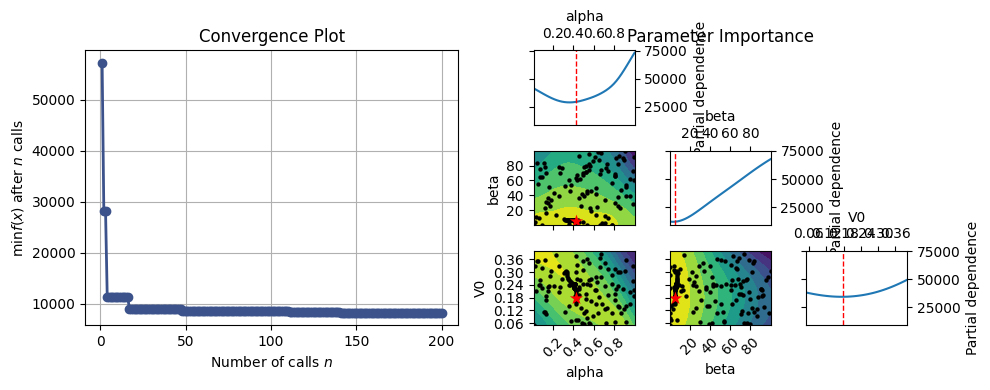

In [27]:
# ### Simple RL agent - forgetting + stickyness
model_name = 'Foraging'
agent_class = ForagingAgent
fixed_params = {'reset_on_switch': False}
param_space = [alpha_range, beta_range, V0_range]#, forgetting_rate_range, forgetting_threshold_range, stickyness_range]

results[model_name], behaviors_simulated[model_name] = fit_simulate(agent_class, param_space, env, behav_monkey, fixed_params, CV_splits=cv_splits, strict=False, make_plots=True, 
                                                                    n_calls=200, n_initial_points=100, n_jobs=n_jobs, verbose=False)

In [29]:
print(results[model_name]['LPT_best'])
results[model_name].to_dict()

0.5799399362584164


{'alpha': 0.42459568244690393,
 'beta': 5.4725455467562,
 'V0': 0.17807545098094152,
 'LL_best': -8256.90984923181,
 'BIC_best': 16542.697955832096,
 'LPT_best': 0.5799399362584164,
 'Reward rate': 0.49704,
 'Proba best': 0.57266}

0.579859494431242
{'alpha': 0.43625095850064205,
 'beta': 5.535352836316126,
 'V0': 0.17329052460423172,
 'LL_best': -8259.012102191286,
 'BIC_best': 16546.902461751048,
 'LPT_best': 0.579859494431242,
 'Reward rate': 0.5013,
 'Proba best': 0.5843}

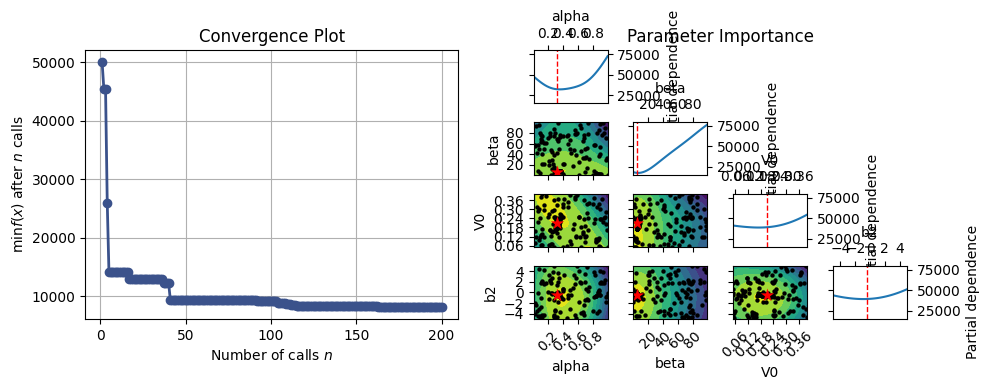

In [25]:
# ### Simple RL agent - forgetting + stickyness
model_name = 'Foraging'
agent_class = ForagingAgent
fixed_params = {'reset_on_switch': False}
param_space = [alpha_range, beta_range, V0_range, b2_range]#, forgetting_rate_range, forgetting_threshold_range, stickyness_range]

results[model_name], behaviors_simulated[model_name] = fit_simulate(agent_class, param_space, env, behav_monkey, fixed_params, CV_splits=cv_splits, strict=False, make_plots=True, 
                                                                    n_calls=200, n_initial_points=100, n_jobs=n_jobs, verbose=False)

In [26]:
print(results[model_name]['LPT_best'])
results[model_name].to_dict()

0.5806906007767164


{'alpha': 0.32690759131930586,
 'beta': 5.932556330824664,
 'V0': 0.21200859282003376,
 'b2': -0.4351184627292639,
 'LL_best': -8237.306156242317,
 'BIC_best': 16513.116655642603,
 'LPT_best': 0.5806906007767164,
 'Reward rate': 0.48916,
 'Proba best': 0.55862}